In [2]:
import scipy.io as sio

# data = sio.loadmat("data/FLIC/examples.mat")
data = sio.loadmat("data/FLIC-full/examples.mat")

print(data.keys())

examples = data["examples"]

FileNotFoundError: [Errno 2] No such file or directory: 'data/FLIC-full/examples.mat'

data\FLIC-full\images\12-oclock-high-special-edition-00004151.jpg
Trying: data\FLIC-full\images\12-oclock-high-special-edition-00004151.jpg
Exists: True


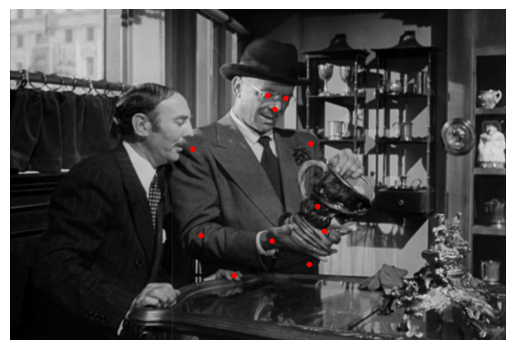

In [2]:
import os
import cv2
import matplotlib.pyplot as plt

ex = examples[0, 0]

# Decode filepath
fp = ex["filepath"][0]
if isinstance(fp, bytes):
    fp = fp.decode("utf-8")

# ALWAYS assume images live in images/
img_path = os.path.join("data", "FLIC-full", "images", fp)

print(img_path)

print("Trying:", img_path)
print("Exists:", os.path.exists(img_path))

img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

coords = ex["coords"]
for i in range(coords.shape[1]):
    x, y = coords[:, i]
    if x > 0 and y > 0:
        cv2.circle(img, (int(x), int(y)), 4, (255, 0, 0), -1)

plt.imshow(img)
plt.axis("off")
plt.show()


In [3]:
print(coords)

[[436.58776855 446.54693604 456.50613403 265.28979492 277.24081421
  380.81634521 434.59591675          nan          nan 325.04492188
           nan          nan 400.73471069 374.84082031          nan
           nan 384.80001831          nan          nan          nan
           nan          nan          nan          nan          nan
           nan          nan          nan          nan]
 [195.15625    286.796875   322.65625    203.125      328.6328125
  336.6015625  370.46875             nan          nan 386.40625
           nan          nan 129.4140625  125.4296875           nan
           nan 145.3515625           nan          nan          nan
           nan          nan          nan          nan          nan
           nan          nan          nan          nan]]


In [47]:
import numpy as np

dataset = []

num_samples = examples.shape[1]

for i in range(num_samples):
    ex = examples[0, i]

    filepath = ex['filepath'][0]

    coords = np.squeeze(ex['coords'])   # (2, 29)
    keypoints = coords.T                # (29, 2)

    dataset.append((filepath, keypoints))

In [48]:
print(dataset[0][1].shape)

(29, 2)


In [49]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

image_size = (128, 128)
num_joints = 29

images_folder = "data/FLIC-full/images"

def load_image_and_keypoints(filename, keypoints, folder=images_folder):
    filepath = os.path.join(folder, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File does not exist: {filepath}")
    
    img = image.load_img(filepath, target_size=image_size)
    img_array = image.img_to_array(img)

    # Handle missing keypoints
    keypoints = np.nan_to_num(keypoints, nan=0.0)

    # Normalize coordinates to [0,1]
    # keypoints[:, 0] /= image_size[1]  # x / width
    # keypoints[:, 1] /= image_size[0]  # y / height
    
    return img_array, keypoints

In [50]:
dataset[0]

(np.str_('12-oclock-high-special-edition-00004151.jpg'),
 array([[436.58776855, 195.15625   ],
        [446.54693604, 286.796875  ],
        [456.50613403, 322.65625   ],
        [265.28979492, 203.125     ],
        [277.24081421, 328.6328125 ],
        [380.81634521, 336.6015625 ],
        [434.59591675, 370.46875   ],
        [         nan,          nan],
        [         nan,          nan],
        [325.04492188, 386.40625   ],
        [         nan,          nan],
        [         nan,          nan],
        [400.73471069, 129.4140625 ],
        [374.84082031, 125.4296875 ],
        [         nan,          nan],
        [         nan,          nan],
        [384.80001831, 145.3515625 ],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,         

data\FLIC-full\images\funny-girl-dvd-video-00050751.jpg
Trying: data\FLIC-full\images\funny-girl-dvd-video-00050751.jpg
Exists: True


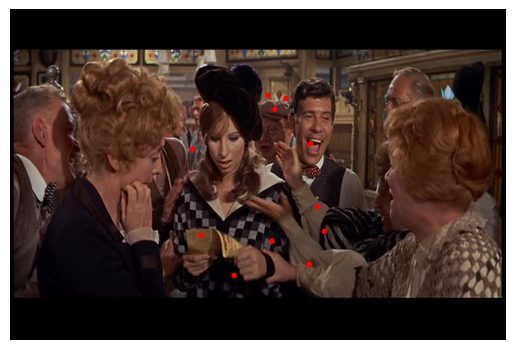

In [20]:
X = []
y = []

print("Started")

for filename, keypoints in dataset:
    img_array, keypoints_norm = load_image_and_keypoints(filename, keypoints, folder=images_folder)
    X.append(img_array)
    y.append(keypoints_norm)

print("Completed")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

12-oclock-high-special-edition-00004151.jpg
12-oclock-high-special-edition-00004221.jpg
12-oclock-high-special-edition-00004281.jpg
12-oclock-high-special-edition-00006331.jpg
12-oclock-high-special-edition-00006361.jpg
12-oclock-high-special-edition-00006371.jpg
12-oclock-high-special-edition-00006381.jpg
12-oclock-high-special-edition-00006391.jpg
12-oclock-high-special-edition-00006401.jpg
12-oclock-high-special-edition-00006411.jpg
12-oclock-high-special-edition-00006421.jpg
12-oclock-high-special-edition-00006431.jpg
12-oclock-high-special-edition-00006661.jpg
12-oclock-high-special-edition-00006701.jpg
12-oclock-high-special-edition-00006771.jpg
12-oclock-high-special-edition-00006811.jpg
12-oclock-high-special-edition-00006821.jpg
12-oclock-high-special-edition-00006831.jpg
12-oclock-high-special-edition-00006851.jpg
12-oclock-high-special-edition-00006861.jpg
12-oclock-high-special-edition-00006891.jpg
12-oclock-high-special-edition-00006901.jpg
12-oclock-high-special-edition-0

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    
    # Use Flatten instead of GlobalAveragePooling to keep spatial info
    tf.keras.layers.Flatten(), 
    
    tf.keras.layers.Dense(512, activation='relu'),
    # Sigmoid forces output between 0 and 1
    tf.keras.layers.Dense(num_joints * 2, activation='sigmoid'), 
    tf.keras.layers.Reshape((num_joints, 2))
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',  # L2 loss for keypoint regression
    metrics=['mae']             # optional, mean absolute error
)

In [ ]:
history = model.fit(
    X, y,
    batch_size=16,
    epochs=50,
    validation_split=0.2,
    shuffle=True
)

In [ ]:
# Save model
model.save("pose_model.keras")

In [26]:
print(X)

[[[[202. 202. 202.]
   [200. 200. 200.]
   [154. 154. 154.]
   ...
   [ 34.  34.  34.]
   [ 36.  36.  36.]
   [ 36.  36.  36.]]

  [[204. 204. 204.]
   [197. 197. 197.]
   [152. 152. 152.]
   ...
   [ 32.  32.  32.]
   [ 34.  34.  34.]
   [ 36.  36.  36.]]

  [[203. 203. 203.]
   [196. 196. 196.]
   [152. 152. 152.]
   ...
   [ 34.  34.  34.]
   [ 34.  34.  34.]
   [ 33.  33.  33.]]

  ...

  [[  1.   1.   1.]
   [  0.   0.   0.]
   [  1.   1.   1.]
   ...
   [ 78.  78.  78.]
   [ 74.  74.  74.]
   [ 56.  56.  56.]]

  [[  2.   2.   2.]
   [  2.   2.   2.]
   [  3.   3.   3.]
   ...
   [ 74.  74.  74.]
   [ 59.  59.  59.]
   [ 48.  48.  48.]]

  [[  1.   1.   1.]
   [  2.   2.   2.]
   [  0.   0.   0.]
   ...
   [ 54.  54.  54.]
   [ 55.  55.  55.]
   [ 33.  33.  33.]]]


 [[[203. 203. 203.]
   [200. 200. 200.]
   [155. 155. 155.]
   ...
   [ 39.  39.  39.]
   [ 41.  41.  41.]
   [ 39.  39.  39.]]

  [[204. 204. 204.]
   [197. 197. 197.]
   [154. 154. 154.]
   ...
   [ 39.  39.  39.]
 

In [27]:
X

array([[[[202., 202., 202.],
         [200., 200., 200.],
         [154., 154., 154.],
         ...,
         [ 34.,  34.,  34.],
         [ 36.,  36.,  36.],
         [ 36.,  36.,  36.]],

        [[204., 204., 204.],
         [197., 197., 197.],
         [152., 152., 152.],
         ...,
         [ 32.,  32.,  32.],
         [ 34.,  34.,  34.],
         [ 36.,  36.,  36.]],

        [[203., 203., 203.],
         [196., 196., 196.],
         [152., 152., 152.],
         ...,
         [ 34.,  34.,  34.],
         [ 34.,  34.,  34.],
         [ 33.,  33.,  33.]],

        ...,

        [[  1.,   1.,   1.],
         [  0.,   0.,   0.],
         [  1.,   1.,   1.],
         ...,
         [ 78.,  78.,  78.],
         [ 74.,  74.,  74.],
         [ 56.,  56.,  56.]],

        [[  2.,   2.,   2.],
         [  2.,   2.,   2.],
         [  3.,   3.,   3.],
         ...,
         [ 74.,  74.,  74.],
         [ 59.,  59.,  59.],
         [ 48.,  48.,  48.]],

        [[  1.,   1.,   1.],
       

In [43]:
import tensorflow as tf

# Load saved model
model = tf.keras.models.load_model("pose_model.keras")

print("Model loaded successfully")

# model.summary()

dataset_size = len(X)
train_size = int(0.8 * dataset_size)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

print(X_train)

# Run inference
predictions = model.predict(X_test)

# print("Prediction shape:", predictions.shape)

Model loaded successfully


IndexError: invalid index to scalar variable.

In [33]:
predictions[0]

array([[ 4.0439558e+00,  1.8358467e+00],
       [ 4.1178775e+00,  2.5412951e+00],
       [ 3.9995556e+00,  2.9502177e+00],
       [ 3.3160796e+00,  1.8810169e+00],
       [ 3.2636678e+00,  2.6027668e+00],
       [ 3.3621788e+00,  2.9308016e+00],
       [ 3.9589937e+00,  2.8910353e+00],
       [-2.9401293e-03,  1.3831346e-03],
       [ 6.5306062e-04, -8.1764441e-04],
       [ 3.3760064e+00,  2.9018037e+00],
       [-6.5731024e-04, -2.3809134e-04],
       [-3.3394643e-04, -1.3451462e-03],
       [ 3.6506920e+00,  1.3191855e+00],
       [ 3.5279772e+00,  1.3279139e+00],
       [ 8.0227456e-04,  2.5430268e-03],
       [-3.6144676e-03, -1.4987430e-03],
       [ 3.5913424e+00,  1.4234135e+00],
       [-6.2930852e-04,  3.5146677e-03],
       [ 1.5299867e-03, -4.8377982e-04],
       [-5.6585064e-05, -6.9492531e-04],
       [ 1.7269417e-03,  2.2080904e-03],
       [ 3.1289272e-04, -1.4541604e-03],
       [-5.9183314e-04,  5.9185654e-04],
       [ 9.0267940e-04,  5.5020163e-04],
       [-2.84848

In [34]:
print(predictions.shape)

(4186, 29, 2)


In [25]:
print(predictions)

[[[ 4.0439558e+00  1.8358467e+00]
  [ 4.1178775e+00  2.5412951e+00]
  [ 3.9995556e+00  2.9502177e+00]
  ...
  [ 4.9059163e-04  1.0162725e-03]
  [ 1.9117221e-04  1.3688251e-03]
  [-1.8562706e-03 -4.0992629e-05]]

 [[ 3.3919253e+00  1.8281269e+00]
  [ 3.5151381e+00  2.5739970e+00]
  [ 3.3595912e+00  2.8417087e+00]
  ...
  [ 8.1897597e-04  5.5797491e-04]
  [-4.1193265e-04  4.2289711e-04]
  [-7.2538119e-04  2.9453984e-04]]

 [[ 3.5970833e+00  1.6623321e+00]
  [ 3.6566150e+00  2.3292930e+00]
  [ 3.5032940e+00  2.5959017e+00]
  ...
  [ 4.5084627e-04  6.4821867e-04]
  [-1.7631582e-04  8.8066119e-04]
  [-1.0663542e-03  6.5261289e-04]]

 ...

 [[ 2.9604287e+00  1.5422072e+00]
  [ 3.1147125e+00  2.2813115e+00]
  [ 3.0136921e+00  2.6882617e+00]
  ...
  [ 1.9383826e-04  7.4439112e-04]
  [ 2.3460056e-04  5.6027906e-04]
  [-6.8062136e-04 -2.0497874e-04]]

 [[ 2.9604290e+00  1.5422072e+00]
  [ 3.1147120e+00  2.2813118e+00]
  [ 3.0136921e+00  2.6882625e+00]
  ...
  [ 1.9384769e-04  7.4439822e-04]
  [ 

In [15]:
predictions = predictions.reshape(-1, 29, 2)

In [16]:
predictions_px = predictions.copy()

predictions_px[:,:,0] *= image_size[1]   # x * width
predictions_px[:,:,1] *= image_size[0]   # y * height

In [23]:
print("Prediction:", predictions_px[0])
print("Ground truth:", y_test[0])

Prediction: [[ 5.17626343e+02  2.34988373e+02]
 [ 5.27088318e+02  3.25285767e+02]
 [ 5.11943115e+02  3.77627869e+02]
 [ 4.24458191e+02  2.40770157e+02]
 [ 4.17749481e+02  3.33154144e+02]
 [ 4.30358887e+02  3.75142609e+02]
 [ 5.06751190e+02  3.70052521e+02]
 [-3.76336545e-01  1.77041233e-01]
 [ 8.35917592e-02 -1.04658484e-01]
 [ 4.32128815e+02  3.71430878e+02]
 [-8.41357112e-02 -3.04756910e-02]
 [-4.27451432e-02 -1.72178715e-01]
 [ 4.67288574e+02  1.68855743e+02]
 [ 4.51581085e+02  1.69972977e+02]
 [ 1.02691144e-01  3.25507432e-01]
 [-4.62651849e-01 -1.91839099e-01]
 [ 4.59691833e+02  1.82196930e+02]
 [-8.05514902e-02  4.49877471e-01]
 [ 1.95838302e-01 -6.19238168e-02]
 [-7.24288821e-03 -8.89504403e-02]
 [ 2.21048534e-01  2.82635570e-01]
 [ 4.00502682e-02 -1.86132535e-01]
 [-7.57546425e-02  7.57576376e-02]
 [ 1.15542963e-01  7.04258084e-02]
 [-3.64605933e-02 -1.69409782e-01]
 [ 4.33245808e-01  1.06506623e-01]
 [ 6.27957284e-02  1.30082875e-01]
 [ 2.44700424e-02  1.75209612e-01]
 [-2.376

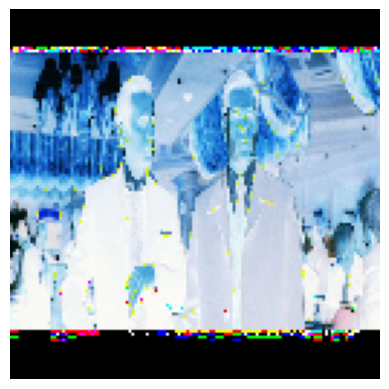

In [35]:
import cv2
import matplotlib.pyplot as plt

img = (X_test[0] * 255).astype("uint8")

pred = predictions[i] * 100

for x, y in pred:
    if x > 1 and y > 1:
        cv2.circle(img, (int(x), int(y)), 4, (255,0,0), -1)

plt.imshow(img)
plt.axis("off")
plt.show()

Skipping joint 7: Coordinate is NaN
Skipping joint 8: Coordinate is NaN
Skipping joint 10: Coordinate is NaN
Skipping joint 11: Coordinate is NaN
Skipping joint 14: Coordinate is NaN
Skipping joint 15: Coordinate is NaN
Skipping joint 17: Coordinate is NaN
Skipping joint 18: Coordinate is NaN
Skipping joint 19: Coordinate is NaN
Skipping joint 20: Coordinate is NaN
Skipping joint 21: Coordinate is NaN
Skipping joint 22: Coordinate is NaN
Skipping joint 23: Coordinate is NaN
Skipping joint 24: Coordinate is NaN
Skipping joint 25: Coordinate is NaN
Skipping joint 26: Coordinate is NaN
Skipping joint 27: Coordinate is NaN
Skipping joint 28: Coordinate is NaN


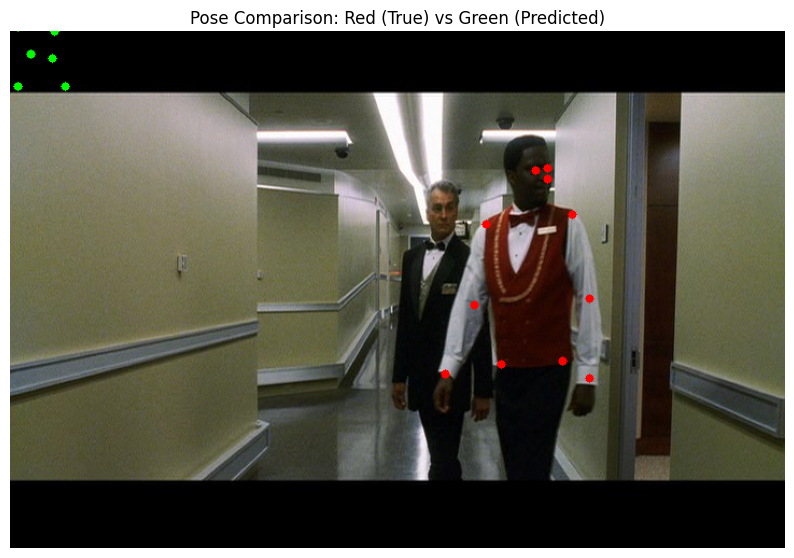

In [42]:
import os
import cv2
import matplotlib.pyplot as plt

# 1. Pick an example from your metadata
# Make sure this index matches the one used in your test split if possible
ex = examples[0, train_size + 5] 

# 2. Resolve Path
fp = ex["filepath"][0]
if isinstance(fp, bytes):
    fp = fp.decode("utf-8")

img_path = os.path.join("data", "FLIC-full", "images", fp)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 3. Get Ground Truth (True labels)
coords_true = ex["coords"] 

# 4. Get Prediction
# Note: Since 'predictions' is likely from X_test, ensure the index aligns
# If predictions[5] corresponds to ex at train_size + 5:
pred_coords = predictions[5] * 100

# 5. Draw Ground Truth (Red)
for i in range(coords_true.shape[1]):
    tx, ty = coords_true[:, i]
    if not np.isnan(tx) and not np.isnan(ty):
        cv2.circle(img, (int(tx), int(ty)), 4, (255, 0, 0), -1)
    else:
        print(f"Skipping joint {i}: Coordinate is NaN")

# 6. Draw Model Predictions (Green)
# Scale normalized predictions (0-1) to the actual image dimensions
h, w, _ = img.shape
for px, py in pred_coords:
    # Scale back to pixel values
    scaled_x = int(px * w)
    scaled_y = int(py * h)
    cv2.circle(img, (scaled_x, scaled_y), 4, (0, 255, 0), -1)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title("Pose Comparison: Red (True) vs Green (Predicted)")
plt.axis("off")
plt.show()